# 5. Cross-check against NaMaster, performance, and large maps

GMaster reimplements NaMaster on the GPU, so the first thing to check is that the two give the same
answer on the same inputs. This notebook runs both side by side (it needs `pymaster` installed), then
covers the settings that matter for large maps.

In [1]:
import os
os.environ.setdefault("JAX_ENABLE_X64", "1")   # NaMaster-level double precision; set before importing JAX

import time
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import jax
import gmaster as nmt

print("GMaster", nmt.__version__, "| JAX", jax.__version__, "| device:", jax.devices()[0].device_kind)
import pymaster
print("NaMaster", pymaster.__version__, "| CPU threads available:", os.cpu_count(),
      "| OMP_NUM_THREADS =", os.environ.get("OMP_NUM_THREADS", "unset"))

GMaster 1.0.0 | JAX 0.10.0 | device: NVIDIA RTX PRO 6000 Blackwell Workstation Edition
NaMaster 3.0 | CPU threads available: 192 | OMP_NUM_THREADS = 32


In [2]:
import camb

def camb_spectra(lmax, r=0.0):
    """Lensed CMB C_ell in muK^2 (TT, EE, BB, TE) for a Planck-2018-like cosmology, ell = 0..lmax."""
    pars = camb.set_params(H0=67.4, ombh2=0.0224, omch2=0.120, mnu=0.06, omk=0, tau=0.054,
                           As=2.1e-9, ns=0.965, r=r, lmax=lmax + 500, WantTensors=r > 0)
    res = camb.get_results(pars)
    cl = res.get_cmb_power_spectra(pars, CMB_unit="muK", raw_cl=True, lmax=lmax)["total"]
    return {k: cl[:, i] for i, k in enumerate(["TT", "EE", "BB", "TE"])}

nside = 512
lmax = 3 * nside - 1
cl = camb_spectra(lmax)
np.random.seed(3)
T, Q, U = hp.synfast([cl["TT"], cl["EE"], cl["BB"], cl["TE"]], nside, lmax=lmax, new=True, pol=True)
theta, phi = hp.pix2ang(nside, np.arange(hp.nside2npix(nside)))
mask = pymaster.mask_apodization((np.abs(90.0 - np.degrees(theta)) > 20.0).astype(float), 1.0, apotype="C1")

## The same estimator, twice

The code below is written once and run with either module. Only the import changes.

In [3]:
def pipeline(lib, mask, maps, nlb=16):
    """Decoupled bandpowers of a masked map: the whole MASTER estimator."""
    bins = lib.NmtBin.from_nside_linear(nside, nlb)
    field = lib.NmtField(mask, maps)
    workspace = lib.NmtWorkspace.from_fields(field, field, bins)
    return np.asarray(workspace.decouple_cell(lib.compute_coupled_cell(field, field)))

def timed(lib, maps, repeats=2):
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        out = pipeline(lib, mask, maps)
        times.append(time.perf_counter() - t0)
    return out, times

rows = []
for label, maps in [("temperature (spin 0)", [T]), ("polarization (spin 2)", [Q, U])]:
    cl_nm, t_nm = timed(pymaster, maps, repeats=1)
    cl_gm, t_gm = timed(nmt, maps, repeats=2)          # the first GMaster call compiles
    rel = np.max(np.abs(cl_gm - cl_nm)) / np.max(np.abs(cl_nm))
    rows.append((label, rel, t_nm[-1], t_gm[0], t_gm[-1]))

print(f"{'field':24s} {'max|GM-NM|/max|NM|':>20s} {'NaMaster [s]':>13s} {'GMaster 1st [s]':>16s} {'GMaster warm [s]':>17s}")
for label, rel, tn, tg1, tg in rows:
    print(f"{label:24s} {rel:20.1e} {tn:13.2f} {tg1:16.2f} {tg:17.2f}")

field                      max|GM-NM|/max|NM|  NaMaster [s]  GMaster 1st [s]  GMaster warm [s]
temperature (spin 0)                  8.6e-08          0.44             4.82              0.02
polarization (spin 2)                 3.6e-07          0.82             7.92              0.04


The two agree to $\sim 10^{-5}$ or better. GMaster's latitudinal transforms run in float32 on the GPU
where that keeps the error below NaMaster's own HEALPix quadrature error. `set_coupling_precision("fp64")`
and `GMASTER_MARCH_V2=0` switch to all-float64 paths if bit-level parity is needed.

These timings come from whatever machine runs this notebook and use the CPU threads NaMaster is given.
For controlled comparisons, see `benchmarks/` and the figure below.

## Scaling with resolution

Warm wall time on one NVIDIA RTX PRO 6000 Blackwell (96 GB) against NaMaster on 32 and 96 cores
of an AMD Ryzen Threadripper PRO 9995WX, each run in an isolated container (see `benchmarks/`). The bottom row is the full
MASTER estimator on the ACT DR6 map and footprint.

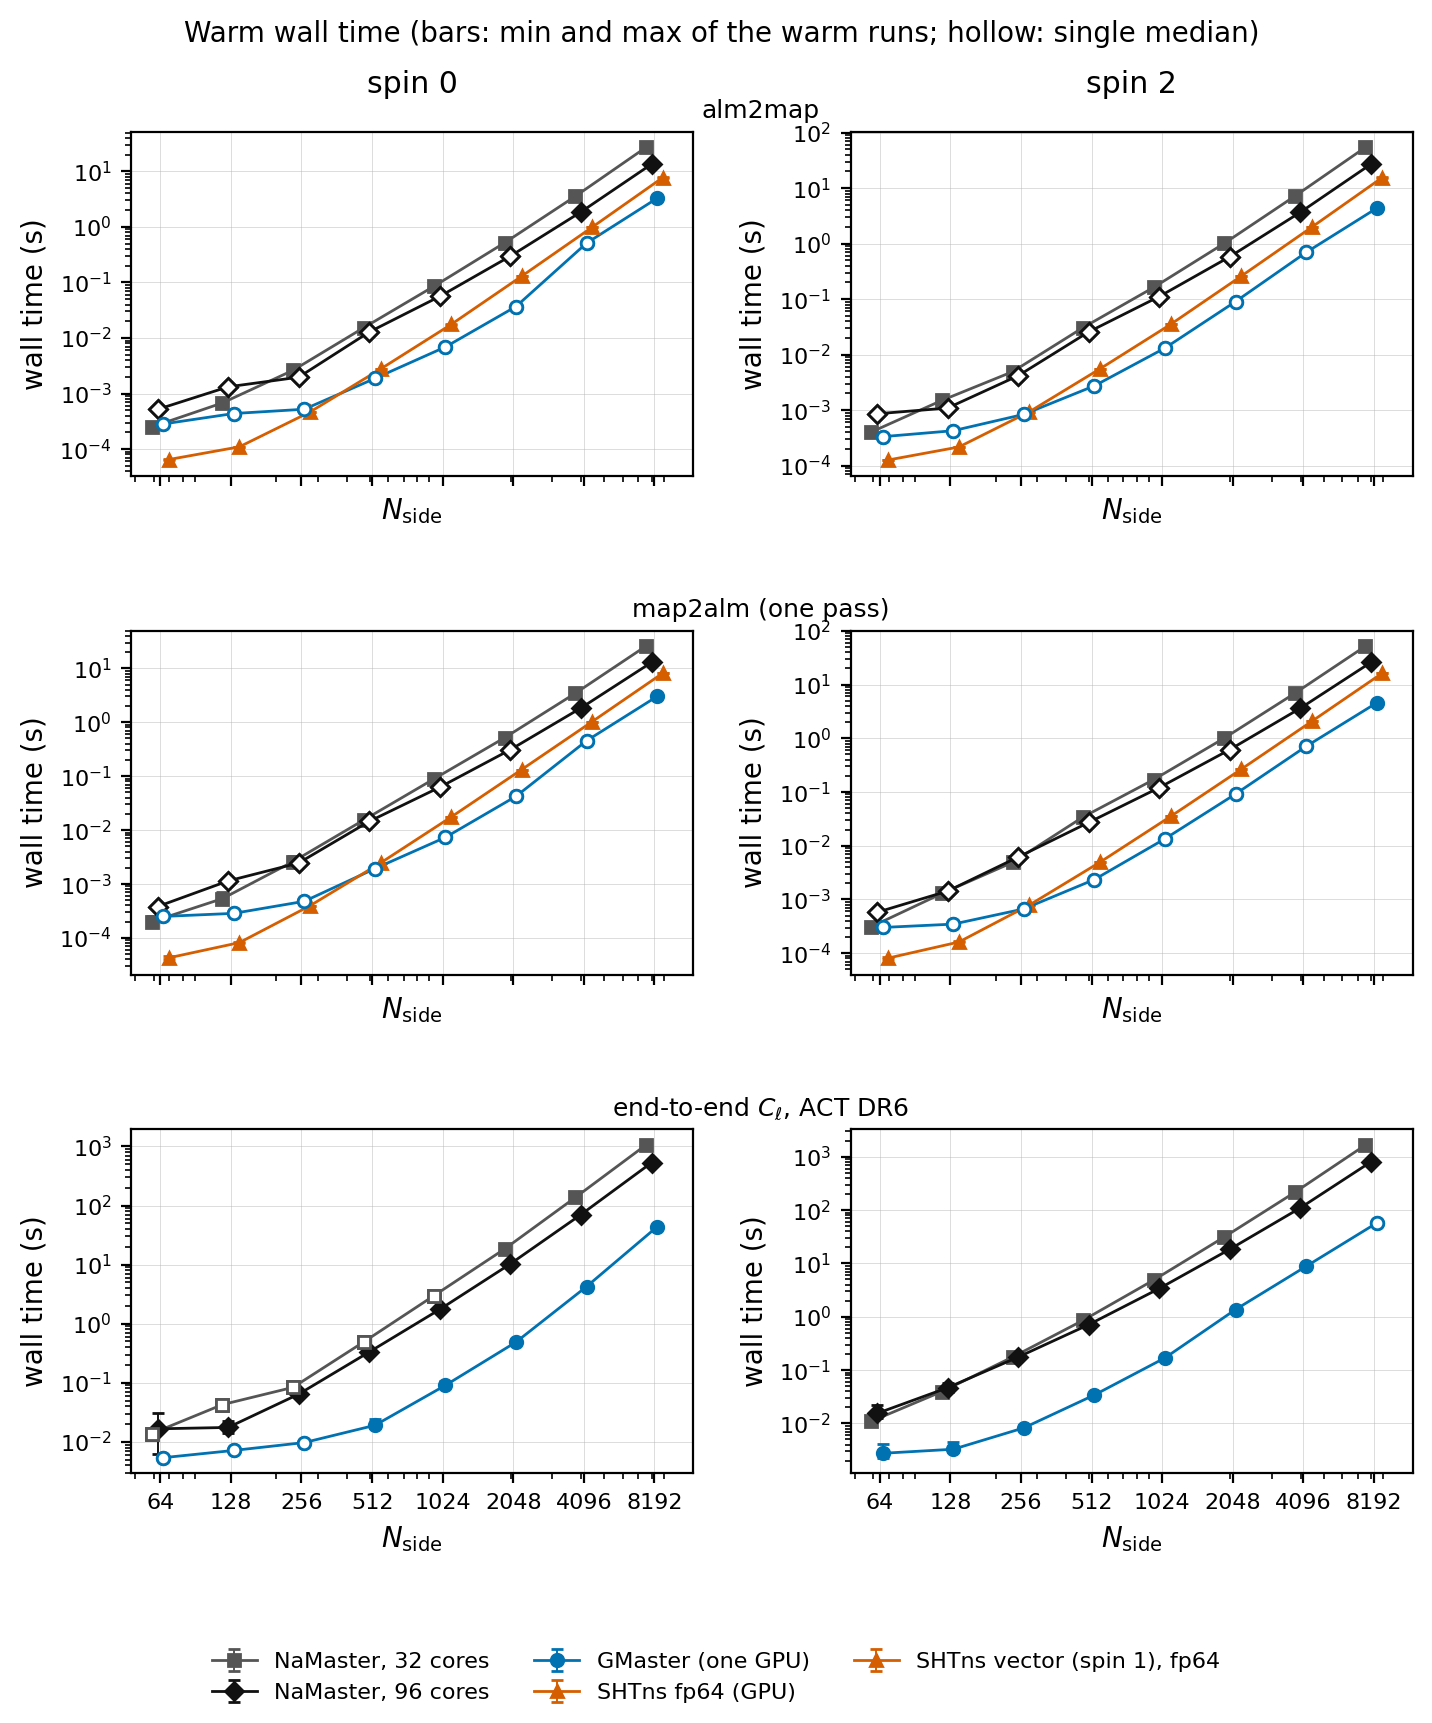

In [4]:
from IPython.display import Image
Image(filename="../docs/figures/time_vs_nside.png", width=800)

## Settings for large maps

| setting | when |
|---|---|
| `JAX_ENABLE_X64=1` | always (set before importing JAX) |
| `XLA_PYTHON_CLIENT_PREALLOCATE=false` | Nside $\geq$ 4096, or a shared GPU: let the pool grow on demand instead of reserving 75% of the card |
| `nmt.set_latitudinal_method("march")` | skip the divide-and-conquer engine. By default it serves Nside 2048-4096 and builds a plan on the host the first time a geometry is used (minutes, then cached in `~/.cache/gmaster`) |
| `nmt.set_n_iter_default(n)` | number of Jacobi iterations of `map2alm` (NaMaster's default is 3) |
| `nmt.set_coupling_precision("fp64")` | float64 coupling matrices (default: float32 operands where the GPU march runs, relative error ~2e-6) |

One GPU with 96 GB runs the full spin-2 MASTER estimator up to Nside 8192 ($\ell_{\max} = 24575$).
The memory figure below shows the peak device memory against NaMaster's host memory.

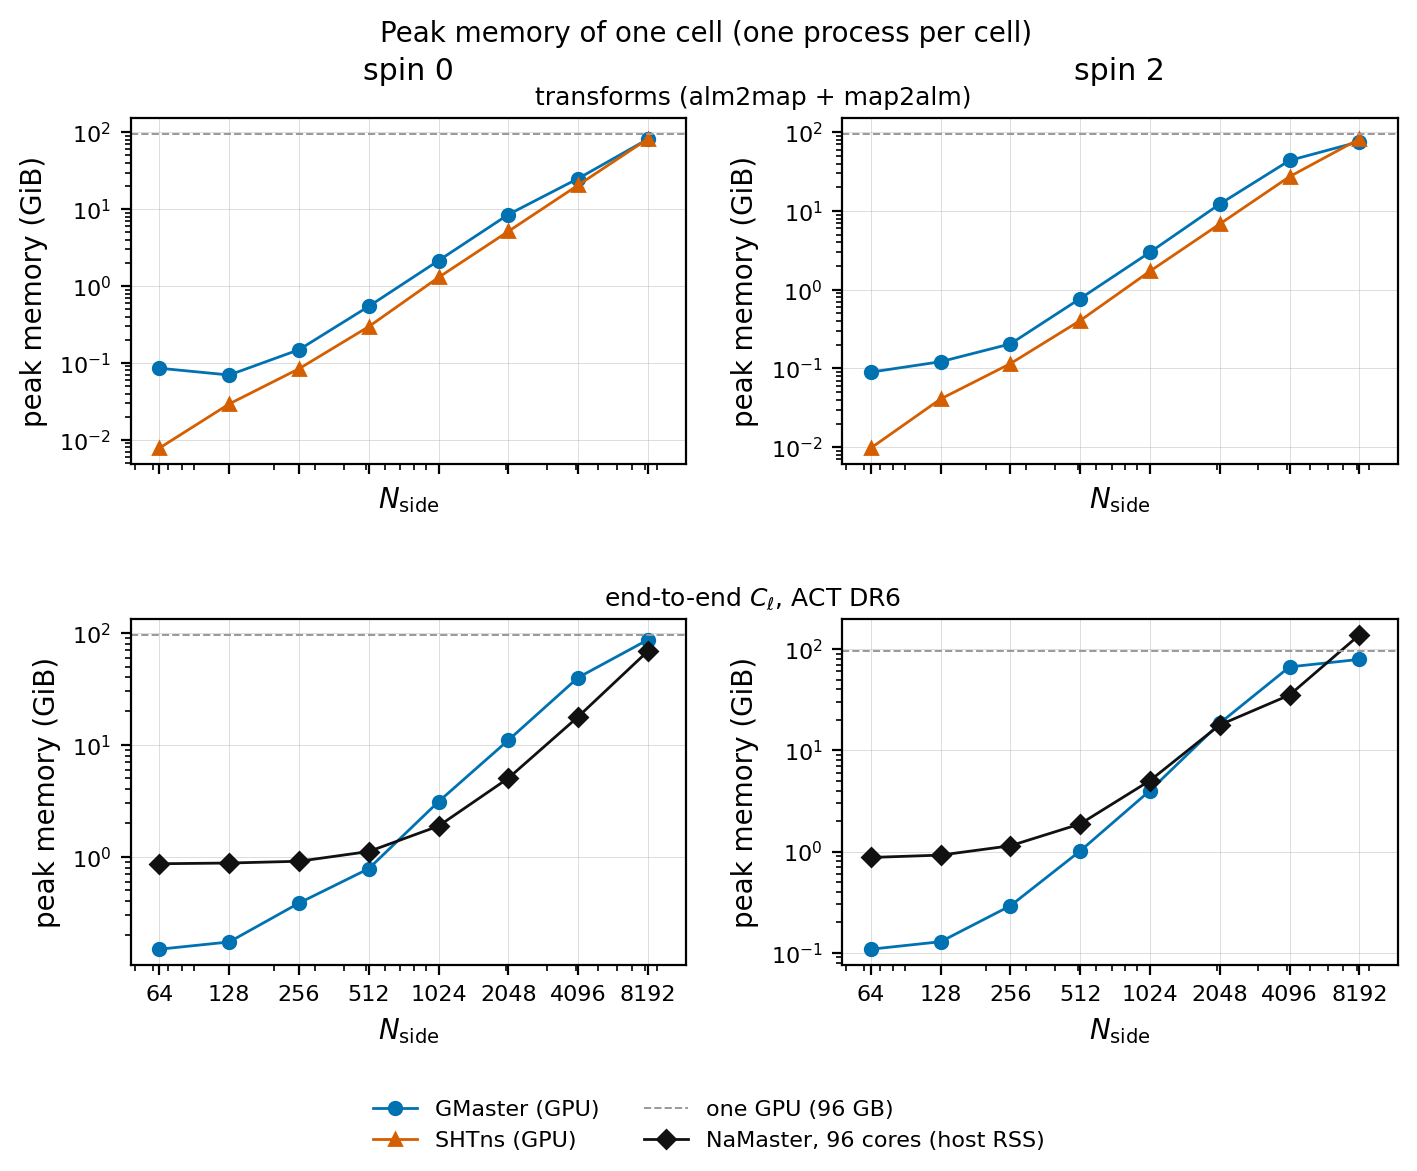

In [5]:
Image(filename="../docs/figures/memory_vs_nside.png", width=800)